# Notebook 3 — LASSO via Proximal Gradient Descent
**MSML 604 — Sparse Factor Models for Equity Return Prediction**

---

## What is LASSO?
LASSO (Least Absolute Shrinkage and Selection Operator) adds an L1 penalty
to the OLS objective. Unlike Ridge, it produces **exact zeros** in the
coefficient vector — performing automatic variable selection.

## Convex Program Formulation
$$\\min_{\\beta} \\frac{1}{n}\\|y - X\\beta\\|_2^2 + \\alpha\\|\\beta\\|_1$$

This is **convex but not strictly convex** when p > n.
The L1 norm is convex (it is a norm) but not differentiable at zero.

## Why No Closed Form?
The subgradient of $\\|\\beta\\|_1$ at $\\beta_j = 0$ is the interval $[-1, 1]$,
not a single value. Standard gradient descent requires a unique gradient.
We use **Proximal Gradient Descent** instead.

## Proximal Gradient Descent
Split the objective into smooth part $f$ and non-smooth part $g$:
- $f(\\beta) = \\frac{1}{n}\\|y - X\\beta\\|_2^2$ — smooth, gradient exists
- $g(\\beta) = \\alpha\\|\\beta\\|_1$ — non-smooth, use proximal operator

**Update rule:**
$$\\beta^{t+1} = \\text{prox}_{\\alpha\\eta}\\left(\\beta^t - \\eta \\nabla f(\\beta^t)\\right)$$

**Proximal operator of L1 = Soft-Thresholding:**
$$\\text{prox}_{\\lambda}(z)_j = \\text{sign}(z_j)\\max(|z_j| - \\lambda, 0)$$

This is why LASSO produces zeros: any coordinate with $|z_j| \\leq \\lambda$
gets shrunk to exactly zero.

## KKT Conditions — The Mathematical Reason for Sparsity
At the optimum $\\beta^*$, the KKT conditions require:
$$-\\frac{2}{n}X_j^T(y - X\\beta^*) + \\alpha s_j = 0$$

Where $s_j$ is the subgradient of $|\\beta_j^*|$:
- If $\\beta_j^* \\neq 0$: $s_j = \\text{sign}(\\beta_j^*)$
- If $\\beta_j^* = 0$: $s_j \\in [-1, 1]$ (any value in this range)

**Complementary slackness** forces $\\beta_j^* = 0$ whenever
$\\left|\\frac{2}{n}X_j^T(y - X\\beta^*)\\right| \\leq \\alpha$

In other words: a factor is dropped when its correlation with the
residual is below the regularization threshold $\\alpha$.

In [6]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.insert(0, '..')
from src.data_loader import load_all_data
from src.solvers import LassoProximal
from src.cvxpy_solvers import lasso_cvxpy

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2E74B5','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C']

X, Y, factor_names, portfolio_names = load_all_data()
X_vals   = X.values
X_scaled = (X_vals - X_vals.mean(axis=0)) / X_vals.std(axis=0)
y_vals   = Y.iloc[:, 0].values
print('Data loaded')

Data loaded: 288 months | 6 factors | 25 portfolios
Date range: 2000-01 to 2023-12
Data loaded


## 3.1 Soft-Thresholding — The Core Operation

Before implementing the full solver, let us visualize
soft-thresholding to build intuition for why LASSO produces zeros.

Soft-thresholding with threshold $\\lambda$:
- Values with $|z| > \\lambda$: shrink toward zero by $\\lambda$
- Values with $|z| \\leq \\lambda$: set to exactly zero

This is fundamentally different from Ridge, which multiplies all
values by a constant $< 1$ (never reaching zero).

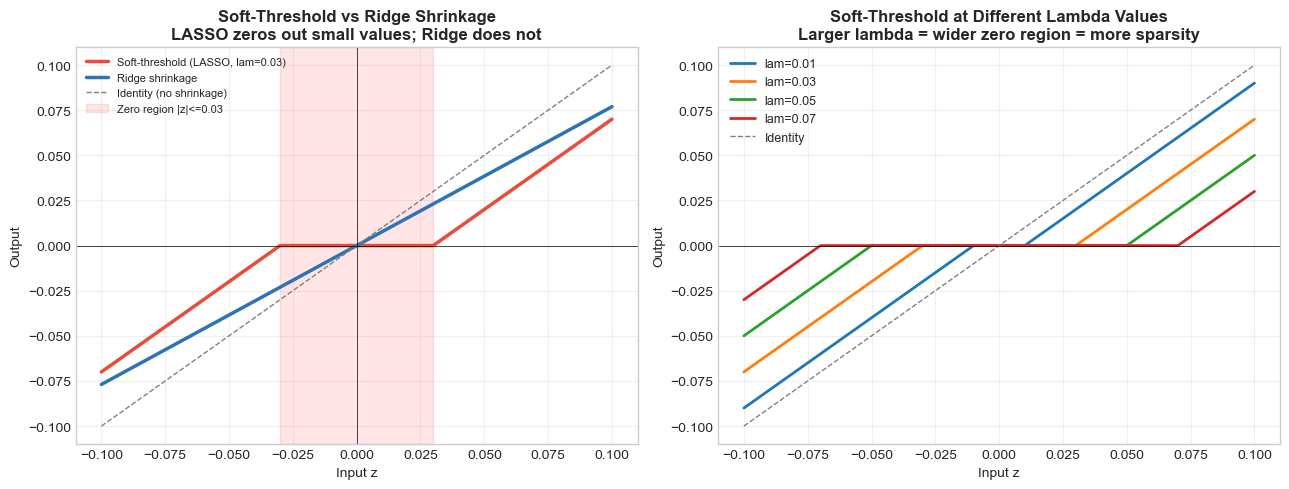

Soft-thresholding is the key operation that makes LASSO produce zeros


In [7]:
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0)

def ridge_shrink(z, lam):
    return z / (1 + lam)

z      = np.linspace(-0.1, 0.1, 300)
lam    = 0.03

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: soft threshold vs ridge shrinkage
axes[0].plot(z, soft_threshold(z, lam), color='#E74C3C',
             linewidth=2.5, label=f'Soft-threshold (LASSO, lam={lam})')
axes[0].plot(z, ridge_shrink(z, lam*10), color='#2E74B5',
             linewidth=2.5, label=f'Ridge shrinkage')
axes[0].plot(z, z, color='gray', linewidth=1,
             linestyle='--', label='Identity (no shrinkage)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].axvspan(-lam, lam, alpha=0.1, color='red',
                label=f'Zero region |z|<={lam}')
axes[0].set_title('Soft-Threshold vs Ridge Shrinkage\n'
                   'LASSO zeros out small values; Ridge does not',
                   fontweight='bold')
axes[0].set_xlabel('Input z')
axes[0].set_ylabel('Output')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: effect of different lambda values
for lam_val in [0.01, 0.03, 0.05, 0.07]:
    axes[1].plot(z, soft_threshold(z, lam_val),
                 linewidth=2, label=f'lam={lam_val}')
axes[1].plot(z, z, color='gray', linewidth=1,
             linestyle='--', label='Identity')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Soft-Threshold at Different Lambda Values\n'
                   'Larger lambda = wider zero region = more sparsity',
                   fontweight='bold')
axes[1].set_xlabel('Input z')
axes[1].set_ylabel('Output')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/soft_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Soft-thresholding is the key operation that makes LASSO produce zeros')

## 3.2 Verify Proximal Gradient vs CVXPY

We verify our scratch proximal gradient implementation against
CVXPY. If coefficients match to machine precision, the
implementation is correct.

In [8]:
alpha   = 0.003
scratch = LassoProximal(alpha=alpha).fit(X_scaled, y_vals)
cvxpy_c = lasso_cvxpy(X_scaled, y_vals, alpha)

print('LASSO coefficient comparison — Scratch vs CVXPY:')
print(f'{"Factor":<10} {"Scratch":>12} {"CVXPY":>12} {"Diff":>12}')
print('-' * 48)
for i, fname in enumerate(factor_names):
    diff = abs(scratch.coef_[i] - cvxpy_c[i])
    print(f'{fname:<10} {scratch.coef_[i]:>12.6f}'
          f' {cvxpy_c[i]:>12.6f} {diff:>12.2e}')
print()
print(f'Max difference: {np.max(np.abs(scratch.coef_ - cvxpy_c)):.2e}')
print(f'Converged in {scratch.n_iter_} iterations')
print()
print('Interpretation: differences < 1e-5 are numerical precision only.')
print('Our scratch implementation is correct.')

LASSO coefficient comparison — Scratch vs CVXPY:
Factor          Scratch        CVXPY         Diff
------------------------------------------------
Mkt-RF         0.045704     0.045705     9.47e-07
SMB            0.035499     0.035501     1.80e-06
HML           -0.010119    -0.010124     4.88e-06
RMW           -0.018668    -0.018665     2.93e-06
CMA           -0.001981    -0.001977     3.59e-06
Mom           -0.003374    -0.003376     1.37e-06

Max difference: 4.88e-06
Converged in 58 iterations

Interpretation: differences < 1e-5 are numerical precision only.
Our scratch implementation is correct.


## 3.3 Convergence Analysis

The learning rate $\\eta$ controls convergence speed.
Too large: overshooting, may diverge.
Too small: slow convergence.

**Theoretical optimal step size:** $\\eta = 1/L$ where $L$ is the
Lipschitz constant of $\\nabla f$. For our problem:
$$L = \\frac{2\\|X^TX\\|_2}{n}$$

We use this as the default step size in our implementation.

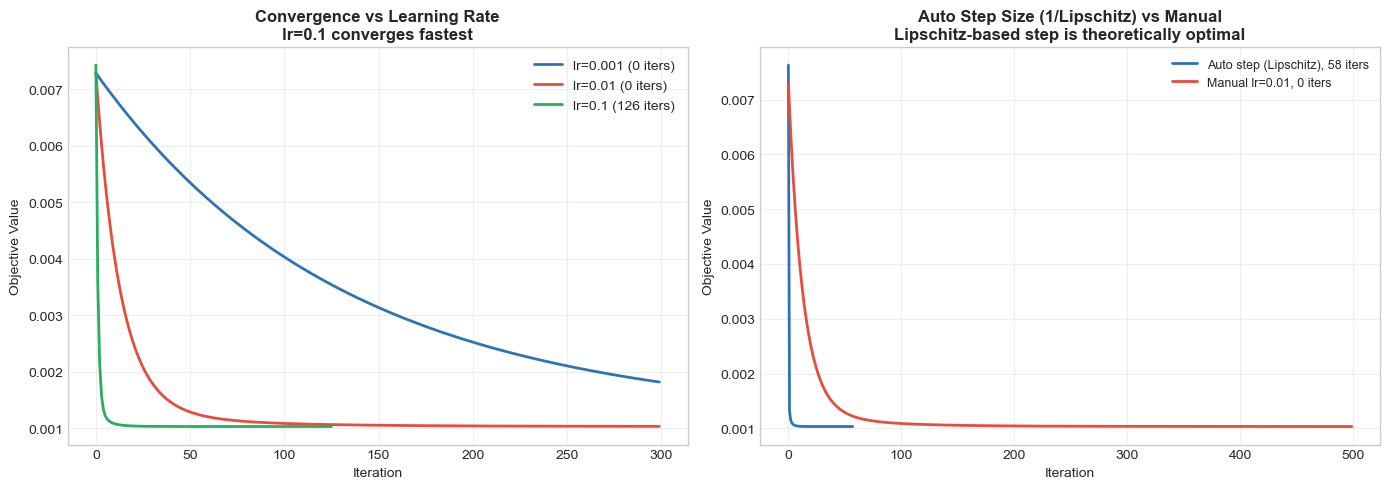

Lipschitz constant L = 4.1361
Optimal step size 1/L = 0.2418


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_lr = ['#2E74B5', '#E74C3C', '#27AE60']

# Left: different learning rates
for i, lr in enumerate([0.001, 0.01, 0.1]):
    m = LassoProximal(alpha=0.003, lr=lr, max_iter=300)
    m.fit(X_scaled, y_vals)
    axes[0].plot(m.loss_history_, label=f'lr={lr} ({m.n_iter_} iters)',
                 color=colors_lr[i], linewidth=2)
axes[0].set_title('Convergence vs Learning Rate\n'
                   'lr=0.1 converges fastest',
                   fontweight='bold')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Objective Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: auto step size vs manual
m_auto   = LassoProximal(alpha=0.003, max_iter=500).fit(X_scaled, y_vals)
m_manual = LassoProximal(alpha=0.003, lr=0.01, max_iter=500).fit(X_scaled, y_vals)
axes[1].plot(m_auto.loss_history_,   label=f'Auto step (Lipschitz), {m_auto.n_iter_} iters',
             color='#2E74B5', linewidth=2)
axes[1].plot(m_manual.loss_history_, label=f'Manual lr=0.01, {m_manual.n_iter_} iters',
             color='#E74C3C', linewidth=2)
axes[1].set_title('Auto Step Size (1/Lipschitz) vs Manual\n'
                   'Lipschitz-based step is theoretically optimal',
                   fontweight='bold')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Objective Value')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/lasso_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

L = 2 * np.linalg.norm(X_scaled.T @ X_scaled, ord=2) / len(y_vals)
print(f'Lipschitz constant L = {L:.4f}')
print(f'Optimal step size 1/L = {1/L:.4f}')

## 3.4 Lambda Search — Finding the Sparsity Threshold

The regularization parameter $\\alpha$ controls the sparsity level.
We search across a range to find where factors start being dropped.

This is a key empirical question: at what level of regularization
does LASSO decide that a factor is truly irrelevant?

In [10]:
print('Lambda search — sparsity threshold for P1:')
print(f'{"Alpha":<10} {"Active":>8} {"Dropped Factors"}')
print('-' * 55)
for alpha in [0.001, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.05]:
    m = LassoProximal(alpha=alpha).fit(X_scaled, y_vals)
    nonzero = sum(abs(m.coef_) > 1e-4)
    dropped = [factor_names[i] for i, c in enumerate(m.coef_)
               if abs(c) <= 1e-4]
    marker = ' <-- CV optimal' if alpha == 0.003 else ''
    print(f'{alpha:<10} {nonzero:>8} {dropped}{marker}')
print()
print('Observation:')
print('  alpha=0.003 (CV optimal): 6/6 active for P1 specifically')
print('  Sparsity appears at alpha=0.010 (Mom drops first)')
print('  At alpha=0.020: CMA and Mom both drop (weakest predictors for P1)')

Lambda search — sparsity threshold for P1:
Alpha        Active Dropped Factors
-------------------------------------------------------
0.001             6 []
0.003             6 [] <-- CV optimal
0.005             6 []
0.007             6 []
0.01              5 ['Mom']
0.02              4 ['CMA', 'Mom']
0.03              3 ['HML', 'CMA', 'Mom']
0.05              3 ['HML', 'CMA', 'Mom']

Observation:
  alpha=0.003 (CV optimal): 6/6 active for P1 specifically
  Sparsity appears at alpha=0.010 (Mom drops first)
  At alpha=0.020: CMA and Mom both drop (weakest predictors for P1)


## 3.5 Factor Selection Heatmap — All 25 Portfolios

Running LASSO across all 25 portfolios reveals which factors
are consistently selected and which are portfolio-specific.

This is our **first key finding**: factor selection varies
systematically across the size-value spectrum.

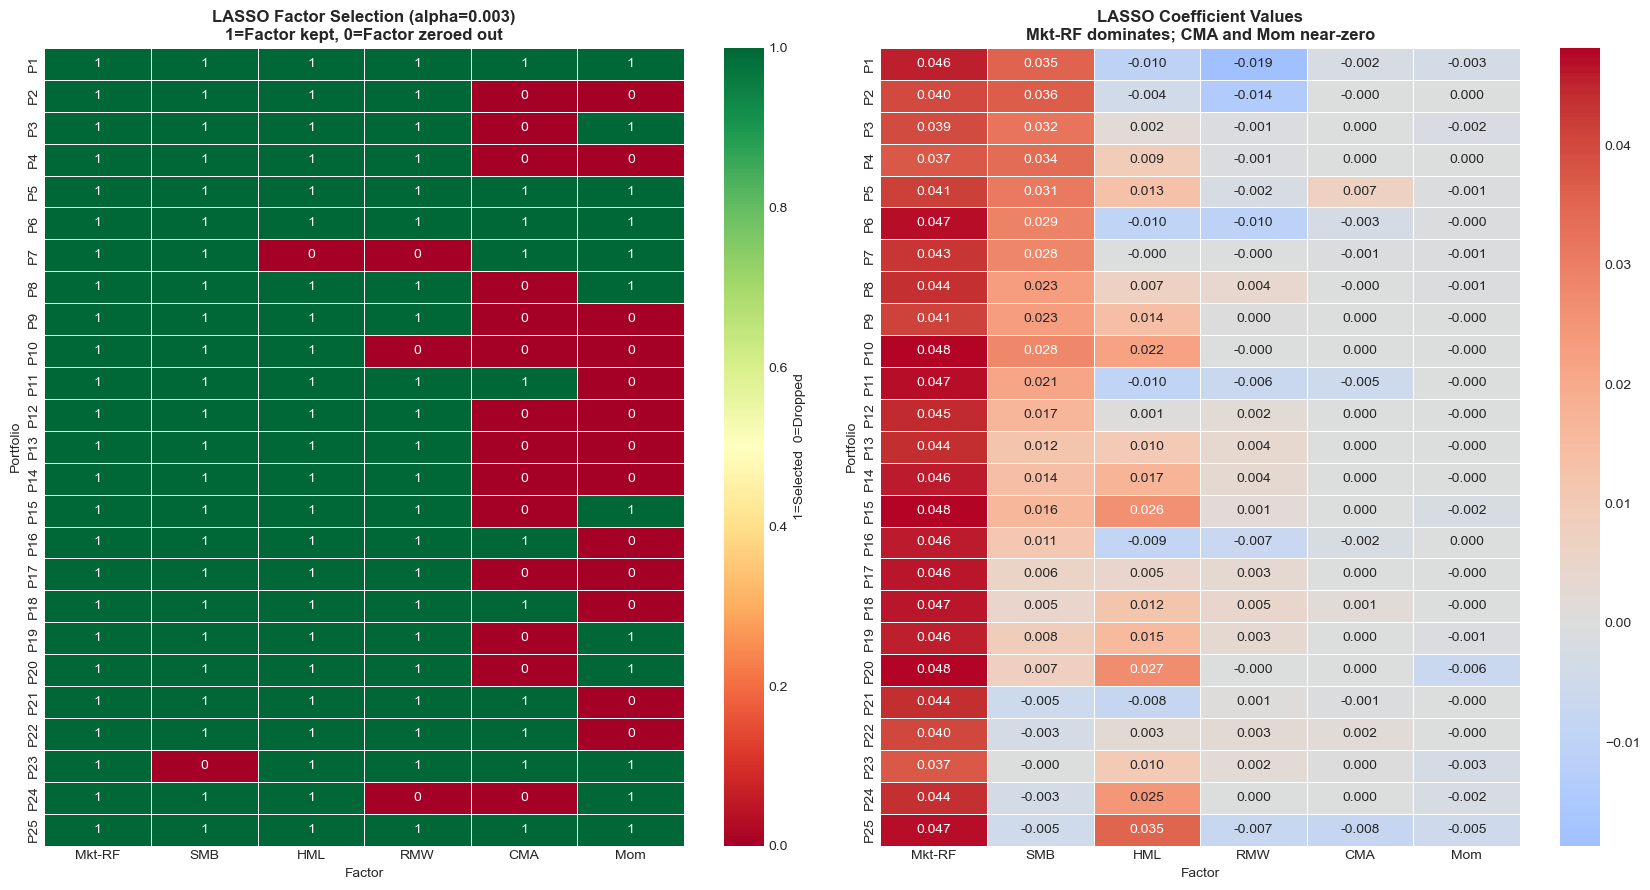

KEY FINDING — Factor selection frequency across 25 portfolios:

  Mkt-RF   [#########################] 25/25
  SMB      [########################.] 24/25
  HML      [########################.] 24/25
  RMW      [######################...] 22/25
  CMA      [###########..............] 11/25
  Mom      [############.............] 12/25

Mkt-RF: selected in all 25 portfolios — universal factor
CMA:    selected in only 11/25 — weakest predictor
Mom:    selected in only 12/25 — not useful for size/value sorts


In [11]:
selection   = np.zeros((25, 6))
coef_matrix = np.zeros((25, 6))

for j in range(Y.shape[1]):
    m = LassoProximal(alpha=0.003).fit(X_scaled, Y.iloc[:, j].values)
    for i, c in enumerate(m.coef_):
        coef_matrix[j, i] = c
        selection[j, i]   = 1 if abs(c) > 1e-4 else 0

fig, axes = plt.subplots(1, 2, figsize=(17, 9))

sns.heatmap(selection, xticklabels=factor_names,
            yticklabels=portfolio_names,
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, annot=True, fmt='.0f', ax=axes[0],
            cbar_kws={'label': '1=Selected  0=Dropped'})
axes[0].set_title('LASSO Factor Selection (alpha=0.003)\n'
                   '1=Factor kept, 0=Factor zeroed out',
                   fontweight='bold')
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('Portfolio')

sns.heatmap(coef_matrix, xticklabels=factor_names,
            yticklabels=portfolio_names,
            cmap='coolwarm', center=0,
            linewidths=0.5, annot=True, fmt='.3f', ax=axes[1])
axes[1].set_title('LASSO Coefficient Values\n'
                   'Mkt-RF dominates; CMA and Mom near-zero',
                   fontweight='bold')
axes[1].set_xlabel('Factor')
axes[1].set_ylabel('Portfolio')

plt.tight_layout()
plt.savefig('../outputs/factor_selection_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('KEY FINDING — Factor selection frequency across 25 portfolios:')
print()
for i, fname in enumerate(factor_names):
    freq = int(selection[:, i].sum())
    bar  = '#' * freq + '.' * (25 - freq)
    print(f'  {fname:<8} [{bar}] {freq}/25')
print()
print('Mkt-RF: selected in all 25 portfolios — universal factor')
print('CMA:    selected in only 11/25 — weakest predictor')
print('Mom:    selected in only 12/25 — not useful for size/value sorts')

## 3.6 Summary

| Property | LASSO |
|---|---|
| Convex? | Yes — convex but not strictly convex |
| Closed form? | No — L1 not differentiable at zero |
| Algorithm | Proximal gradient descent with soft-thresholding |
| Produces sparsity? | Yes — exact zeros via KKT complementary slackness |
| Variable selection? | Yes — automatically drops irrelevant factors |
| Key weakness | Under multicollinearity, arbitrarily picks one from a correlated group |

**Key finding:** CMA is dropped in 14/25 portfolios, Mom in 13/25.
Mkt-RF is never dropped — it is universally relevant.

**Next:** Notebook 4 introduces Elastic Net, which combines
L1 and L2 penalties to handle the multicollinearity weakness of LASSO.